<>:215: SyntaxWarning: invalid escape sequence '\d'
<>:215: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1035561097.py:215: SyntaxWarning: invalid escape sequence '\d'
  numeric_extracted = series.astype(str).str.extract('(\d+\.?\d*)', expand=False)


Available CSV files in /content/:
1: cookie_cats.csv
2: online_gaming_behavior_dataset.csv

Enter the number or exact filename of the CSV file you want to load: 2
Data types:
PlayerID                       int64
Age                            int64
Gender                        object
Location                      object
GameGenre                     object
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                object
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel               object
dtype: object
Dataset shape: (40034, 13)
Target column selected: EngagementLevel
Using target column: EngagementLevel
Preprocessing features...
Features after filtering: 12
Numeric columns: 8
Non-numeric columns: 4
Converting object column to categorical codes
Converting object column to categorical codes
Converting object column to categoric

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


701/701 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5952 - loss: 1.3558 - val_accuracy: 0.8569 - val_loss: 0.6138
Epoch 2/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8144 - loss: 0.6433 - val_accuracy: 0.8624 - val_loss: 0.5036
Epoch 3/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8423 - loss: 0.5416 - val_accuracy: 0.8926 - val_loss: 0.4589
Epoch 4/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8555 - loss: 0.5156 - val_accuracy: 0.8953 - val_loss: 0.4396
Epoch 5/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8614 - loss: 0.4982 - val_accuracy: 0.8922 - val_loss: 0.4385
Epoch 6/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8654 - loss: 0.4853 - val_accuracy: 0.8963 - val_loss: 0.4280
Epoch 7/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8676 - loss: 0.4764 - val_accuracy: 0.8931 - val_loss: 0.4290
Epoch 8/100
701/701 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8683 - loss: 0.4747 - val_accuracy: 0.8899

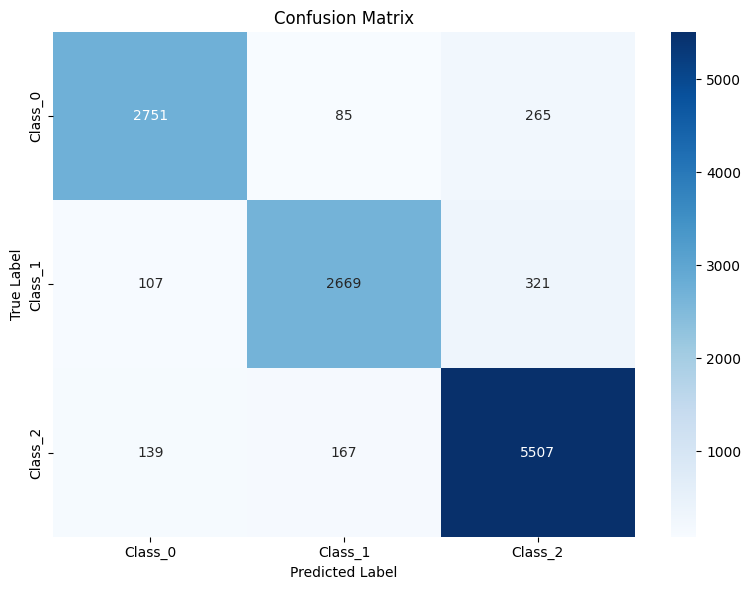


3. Class Distribution Analysis:
Class 0: 3101 samples (25.8%)
Class 1: 3097 samples (25.8%)
Class 2: 5813 samples (48.4%)

5. Data Leakage Check:
Baseline calculation failed: invalid index to scalar variable.


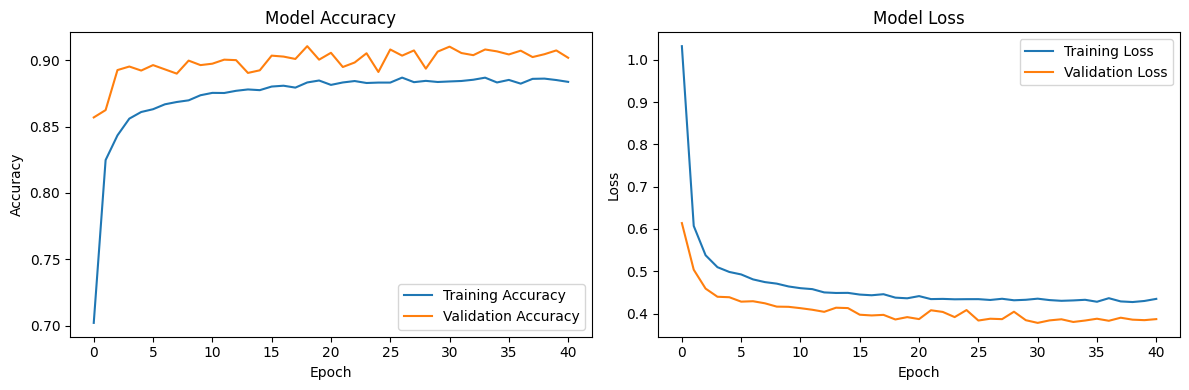

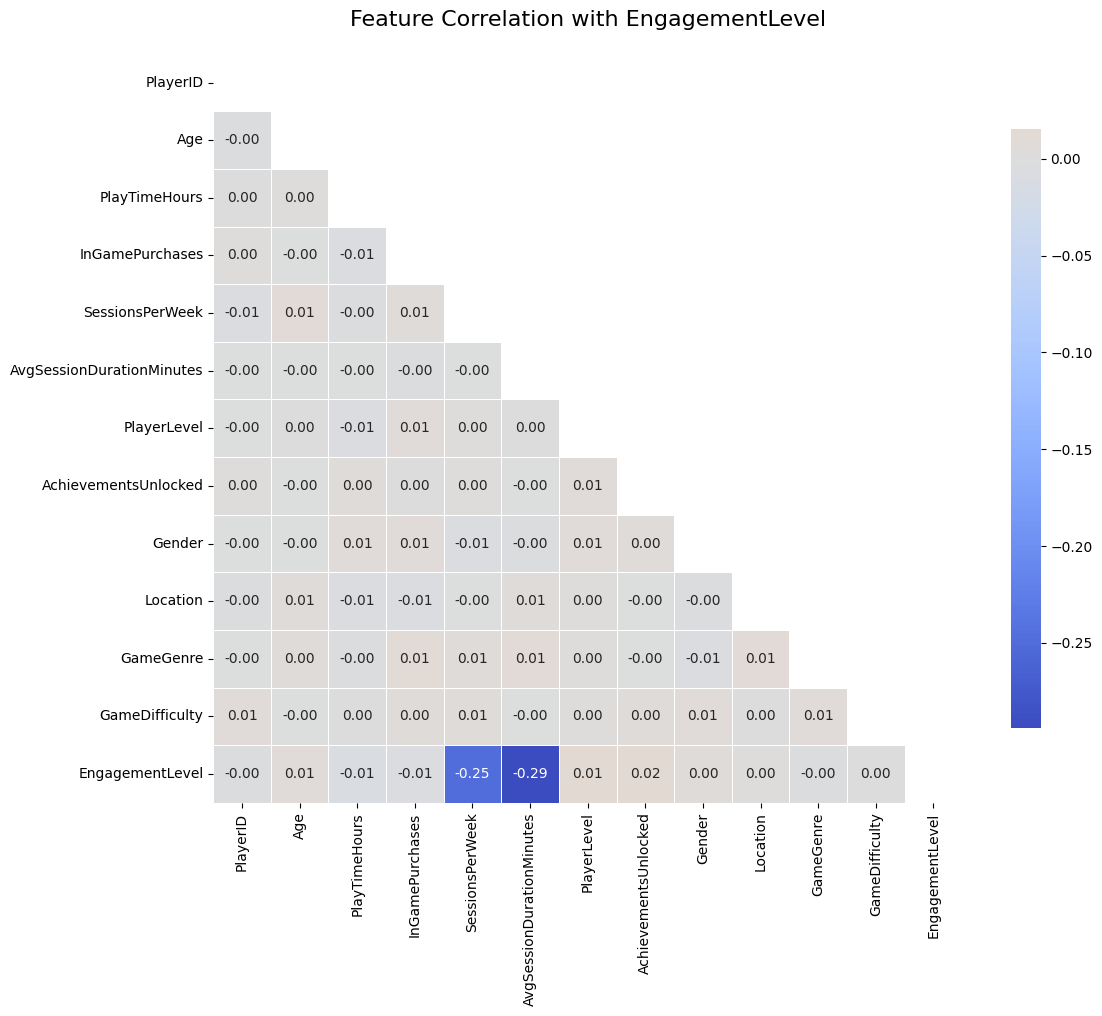


 FINAL TEST ACCURACY: 0.9097

 MODEL SUMMARY:
   Target Column: EngagementLevel
   Feature Columns: ['PlayerID', 'Age', 'PlayTimeHours', 'InGamePurchases', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked', 'Gender', 'Location', 'GameGenre', 'GameDifficulty']
   Target Classes: 4
   Features Used: 12


In [26]:
import os
import numpy as np
import pandas as pd
import random
import re
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import scipy.stats as stats

class ModularDataProcessor:
    def __init__(self, config):
        self.config = config
        self.random_integer = random.randint(1, 100)
        pd.set_option('display.max_columns', None)

    def load_dataset(self):
        """Load dataset with flexible file selection"""
        files = os.listdir('/content/')
        csv_files = [file for file in files if file.endswith('.csv')]

        print("Available CSV files in /content/:")
        for i, file in enumerate(csv_files):
            print(f"{i + 1}: {file}")

        file_choice = input("\nEnter the number or exact filename of the CSV file you want to load: ")

        if file_choice.isdigit():
            index = int(file_choice) - 1
            selected_file = csv_files[index] if 0 <= index < len(csv_files) else None
        else:
            selected_file = file_choice if file_choice in csv_files else None

        if not selected_file:
            raise ValueError("Invalid file selection")

        df = pd.read_csv(f'/content/{selected_file}')
        print(f"Data types:\n{df.dtypes}")
        return df

    def find_target_column(self, df):
        """Flexibly find target column with multiple fallback strategies"""
        # FIXED: Use 'main_column_name' from config, not hardcoded
        target_cols = [col for col in df.columns if self.config['main_column_name'].lower() in col.lower()]

        if not target_cols and self.config.get('secondary_column_key'):
            target_cols = [col for col in df.columns if self.config['secondary_column_key'].lower() in col.lower()]

        if not target_cols:
            common_targets = ['target', 'label', 'class', 'output', 'result', 'category', 'engagement', 'score', 'rating']
            target_cols = [col for col in df.columns if any(word in col.lower() for word in common_targets)]

        if not target_cols:
            numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
            if numeric_cols:
                target_cols = [numeric_cols[-1]]

        if not target_cols:
            for i, col in enumerate(df.columns):
                print(f"{i + 1}: {col} (dtype: {df[col].dtype})")
            choice = input("Enter the number of the column to use as target: ")
            if choice.isdigit() and 1 <= int(choice) <= len(df.columns):
                target_cols = [df.columns[int(choice) - 1]]
            else:
                raise ValueError("Could not find suitable target column.")

        print(f"Target column selected: {target_cols[0]}")
        return target_cols[0]

    def create_balanced_bins(self, data, n_bins):
        """Create balanced bins using quantiles to avoid imbalanced classes"""
        # Remove any NaN or infinite values first
        clean_data = data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(clean_data) == 0:
            raise ValueError("No valid data points after cleaning NaN and infinite values")

        if clean_data.nunique() <= n_bins:
            return clean_data.astype(int)

        # Use quantile-based binning for balanced class distribution
        quantiles = np.linspace(0, 1, n_bins + 1)
        bin_edges = np.quantile(clean_data, quantiles)

        # Ensure unique bin edges
        bin_edges = np.unique(bin_edges)

        if len(bin_edges) < n_bins + 1:
            return self.create_frequency_bins(clean_data, n_bins)

        binned_data = np.digitize(clean_data, bin_edges) - 1
        binned_data = np.clip(binned_data, 0, n_bins - 1)

        return binned_data

    def create_frequency_bins(self, data, n_bins):
        """Create bins with approximately equal frequency"""
        # Remove any NaN or infinite values first
        clean_data = data.replace([np.inf, -np.inf], np.nan).dropna()

        if len(clean_data) == 0:
            raise ValueError("No valid data points after cleaning NaN and infinite values")

        # Sort data and create bins with equal number of samples
        sorted_data = np.sort(clean_data)
        bin_size = len(sorted_data) // n_bins

        bins = []
        for i in range(n_bins):
            if i == n_bins - 1:
                bins.append(sorted_data[-1])
            else:
                bins.append(sorted_data[(i + 1) * bin_size - 1])

        binned_data = np.digitize(clean_data, bins)
        return binned_data

    def prepare_target_variable(self, target_data, n_clusters):
        #This will prepare target variable with balanced binning and robust NaN handling

        # Convert to numeric safely
        target_data = self.safe_convert_to_numeric(target_data)

        # Check for and handle infinite values and NaN
        original_count = len(target_data)
        target_data = target_data.replace([np.inf, -np.inf], np.nan)

        # Count NaN values before filling
        nan_count = target_data.isna().sum()
        if nan_count > 0:
            #print(f"Warning: Found {nan_count} NaN values in target variable ({nan_count/original_count*100:.1f}%)")

            # For small amounts of NaN, use median; for large amounts, consider different strategy
            if nan_count / original_count > 0.1:  # More than 10% NaN
                #print("High percentage of NaN values. Using mode instead of median.")
                fill_value = target_data.mode()[0] if not target_data.mode().empty else 0
            else:
                fill_value = target_data.median()

            target_data = target_data.fillna(fill_value)

        # Check if we have any data left
        if len(target_data) == 0:
            raise ValueError("No valid data points in target variable after cleaning")

        unique_count = target_data.nunique()

        if unique_count > n_clusters:
            try:
                binned_data = self.create_balanced_bins(target_data, n_clusters)

                # Check class distribution
                unique, counts = np.unique(binned_data, return_counts=True)
                class_distribution = dict(zip(unique, counts))

                # Warn if any class has less than 5% of data
                total_samples = len(binned_data)
                for cls, count in class_distribution.items():
                    percentage = (count / total_samples) * 100
                    if percentage < 5:
                        print(f"Warning: Class {cls} has only {percentage:.1f}% of samples")

                return binned_data
            except Exception as e:
                return target_data.astype(int)

        # For non-binned case, ensure we have proper integer values
        try:
            return target_data.astype(int)
        except (ValueError, TypeError) as e:
            return target_data.round().astype(int)

    def safe_convert_to_numeric(self, data):
        #Safely convert data to numeric, handling mixed types and edge cases
        if isinstance(data, pd.DataFrame):
            result = data.copy()
            for col in result.columns:
                result[col] = self._convert_column_to_numeric(result[col])
            return result
        else:
            return self._convert_column_to_numeric(data)

    def _convert_column_to_numeric(self, series):
        """Convert a single column to numeric with robust error handling"""
        # If already numeric, check for issues
        if pd.api.types.is_numeric_dtype(series):
            # Check for infinite values
            if series.isin([np.inf, -np.inf]).any():
                series = series.replace([np.inf, -np.inf], np.nan)
            return series

        # Try direct conversion first
        try:
            converted = pd.to_numeric(series, errors='coerce')
            # Check if conversion was successful (not all NaN)
            if not converted.isna().all():
                return converted
        except Exception as e:
            print(f"Direct conversion failed: {e}")

        # For string data, use categorical encoding
        if series.dtype == 'object':
            print(f"Converting object column to categorical codes")
            try:
                # First try to extract numbers from strings
                numeric_extracted = series.astype(str).str.extract('(\d+\.?\d*)', expand=False)
                numeric_converted = pd.to_numeric(numeric_extracted, errors='coerce')

                # If we got some numeric values, use them
                if not numeric_converted.isna().all():
                    return numeric_converted.fillna(0)
                else:
                    # Otherwise use categorical codes
                    return series.astype('category').cat.codes
            except Exception as e:
                return pd.factorize(series)[0]

        # Final fallback
        try:
            return series.astype(str).astype('category').cat.codes
        except:
            return pd.factorize(series)[0]

    def preprocess_dates(self, df):
        #Process date columns if present
        def process_date(date_val):
            if pd.isna(date_val):
                return date_val
            date_str = str(date_val)
            if date_str.count('/') == 2:
                if len(date_str) <= 4:
                    return date_str
                elif '/' in date_str[:2]:
                    return '0' + date_str[0] + date_str[-4:]
                else:
                    return date_str[:2] + date_str[-4:]
            return date_str

        for col in df.columns:
            col_str = df[col].astype(str)
            if (col_str.str.count('/') == 2).any():
                df[col] = col_str.apply(process_date)
                df[col] = df[col].str.replace('/', '', regex=False)

        return df

    def preprocess_features(self, feature_data):
        #Preprocess feature data handling mixed types
        print("Preprocessing features...")

        # Filter features by unique value count
        feature_data = feature_data.loc[:, feature_data.nunique() <= self.config['max_unique_features']]
        print(f"Features after filtering: {feature_data.shape[1]}")

        # Process dates
        feature_data = self.preprocess_dates(feature_data)

        # Separate numeric and non-numeric data
        numeric_cols = feature_data.select_dtypes(include=['number']).columns
        non_numeric_cols = feature_data.select_dtypes(exclude=['number']).columns

        print(f"Numeric columns: {len(numeric_cols)}")
        print(f"Non-numeric columns: {len(non_numeric_cols)}")

        numeric_data = feature_data[numeric_cols]
        non_numeric_data = feature_data[non_numeric_cols]

        if not non_numeric_data.empty:
            non_numeric_data = self.safe_convert_to_numeric(non_numeric_data)

        # Reduce dimensionality if enabled
        if self.config['data_reduction_enabled']:
            if not numeric_data.empty:
                numeric_data = self.reduce_dimensionality(numeric_data, self.config['numeric_clusters'], 'numeric')
            if not non_numeric_data.empty:
                non_numeric_data = self.reduce_dimensionality(non_numeric_data, self.config['string_clusters'], 'string')

        # Combine all features
        if not numeric_data.empty and not non_numeric_data.empty:
            combined_features = pd.concat([numeric_data, non_numeric_data], axis=1)
        elif not numeric_data.empty:
            combined_features = numeric_data
        else:
            combined_features = non_numeric_data

        # Ensure all data is numeric and handle NaN values
        combined_features = self.safe_convert_to_numeric(combined_features)

        # Fill NaN values with column-specific strategies
        for col in combined_features.columns:
            if combined_features[col].isna().any():
                nan_count = combined_features[col].isna().sum()
                if nan_count / len(combined_features) > 0.5:  # More than 50% NaN
                    # Drop column if too many NaN
                    print(f"Dropping column {col} with {nan_count} NaN values (>50%)")
                    combined_features = combined_features.drop(columns=[col])
                else:
                    # Fill with median for numeric, mode for categorical
                    if pd.api.types.is_numeric_dtype(combined_features[col]):
                        combined_features[col] = combined_features[col].fillna(combined_features[col].median())
                    else:
                        mode_val = combined_features[col].mode()
                        if not mode_val.empty:
                            combined_features[col] = combined_features[col].fillna(mode_val[0])
                        else:
                            combined_features[col] = combined_features[col].fillna(0)

        print(f"Final feature shape: {combined_features.shape}")
        return combined_features

    def reduce_dimensionality(self, data, max_clusters, data_type='numeric'):
        if data.empty:
            return data

        processed_data = data.copy()

        for col in processed_data.columns:
            unique_count = processed_data[col].nunique()

            if unique_count > max_clusters:
                try:
                    if data_type == 'numeric':
                        gmm = GaussianMixture(n_components=max_clusters, random_state=self.random_integer)
                        processed_data[col] = gmm.fit_predict(processed_data[[col]].fillna(0))
                    else:
                        col_data = processed_data[col].fillna(0).values.reshape(-1, 1)
                        kmeans = KMeans(n_clusters=max_clusters, random_state=self.random_integer)
                        processed_data[col] = kmeans.fit_predict(col_data)
                except Exception as e:
                    pass

        return processed_data

    def select_features(self, features, target, n_features):
        #Select features using multiple criteria
        if features.shape[1] <= n_features:
            return features, np.arange(features.shape[1])

        # Use Random Forest for feature importance
        rf = RandomForestClassifier(n_estimators=100, random_state=self.random_integer)
        rf.fit(features, target)
        importances = rf.feature_importances_

        top_indices = np.argsort(importances)[-n_features:]
        return features[:, top_indices], top_indices

    def build_model(self, input_dim, output_dim):
        #Build neural network model with regularization
        model = Sequential([
            Dense(64, activation='relu', input_shape=(input_dim,), kernel_regularizer='l2'),
            Dropout(0.3),
            Dense(32, activation='relu', kernel_regularizer='l2'),
            Dropout(0.2),
            Dense(16, activation='relu'),
            Dropout(0.1),
            Dense(output_dim, activation='softmax')
        ])

        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
        return model

    def validate_results(self, model, X_test, y_test, y_pred, target_names=None):
      """ model results"""
      print("RESULTS")

      # Convert one-hot back to labels for validation
      y_test_labels = np.argmax(y_test, axis=1)
      y_pred_labels = np.argmax(y_pred, axis=1)

      # Get the actual number of classes present in the data
      actual_classes = np.unique(y_test_labels)
      n_actual_classes = len(actual_classes)

      # 1. Basic accuracy
      accuracy = accuracy_score(y_test_labels, y_pred_labels)
      print(f"1. Overall Accuracy: {accuracy:.4f}")

      # 2. Detailed classification report - FIXED: Use actual classes
      print("\n2. Detailed Classification Report:")

      # Create target names based on actual classes present
      if target_names is None or len(target_names) != n_actual_classes:
          actual_target_names = [f'Class_{i}' for i in actual_classes]
          print(f"   Using {n_actual_classes} classes: {actual_target_names}")
      else:
          # If target_names was provided, use only the ones that exist
          actual_target_names = [target_names[i] for i in actual_classes]

      print(classification_report(y_test_labels, y_pred_labels,
                                target_names=actual_target_names,
                                labels=actual_classes))

      # 3. Confusion matrix - FIXED: Use actual classes
      try:
          plt.figure(figsize=(8, 6))
          cm = confusion_matrix(y_test_labels, y_pred_labels, labels=actual_classes)
          sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=actual_target_names,
                    yticklabels=actual_target_names)
          plt.title('Confusion Matrix')
          plt.ylabel('True Label')
          plt.xlabel('Predicted Label')
          plt.tight_layout()
          plt.show()
      except Exception as e:
          print(f"Could not create confusion matrix: {e}")

      # 4. Class distribution analysis
      print("\n3. Class Distribution Analysis:")
      unique, counts = np.unique(y_test_labels, return_counts=True)
      for cls, count in zip(unique, counts):
          percentage = (count / len(y_test_labels)) * 100
          print(f"Class {cls}: {count} samples ({percentage:.1f}%)")

      # 5. Cross-validation with simpler model (if dataset isn't too large)
      if len(X_test) < 10000:
          print("\n4. Cross-Validation Results (Random Forest):")
          try:
              rf = RandomForestClassifier(n_estimators=50, random_state=self.random_integer)
              cv_scores = cross_val_score(rf, X_test, y_test_labels, cv=5, scoring='accuracy')
              print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
          except Exception as e:
              print(f"Cross-validation failed: {e}")

      # 6. Check for data leakage
      print("\n5. Data Leakage Check:")
      feature_correlations = []
      for i in range(X_test.shape[1]):
          try:
              corr = np.corrcoef(X_test[:, i], y_test_labels)[0, 1]
              if not np.isnan(corr):
                  feature_correlations.append(abs(corr))
          except:
              pass

      if feature_correlations and max(feature_correlations) > 0.95:
          print("WARNING: Very high feature correlation detected - possible data leakage!")

      # 7. Baseline comparison (majority class)
      try:
          majority_class = stats.mode(y_test_labels)[0][0]
          baseline_accuracy = np.mean(y_test_labels == majority_class)
          print(f"\n6. Baseline (Majority Class) Accuracy: {baseline_accuracy:.4f}")
          print(f"Model improvement over baseline: {accuracy - baseline_accuracy:.4f}")
      except Exception as e:
          print(f"Baseline calculation failed: {e}")

      return accuracy

def plot_correlation_heatmap_safe(data, title="Correlation Matrix"):
    """Safe correlation heatmap plotting with error handling"""
    try:
        # Ensure data is numeric
        numeric_data = data.select_dtypes(include=[np.number])

        if numeric_data.empty:
            print("No numeric columns for correlation heatmap")
            return

        # Calculate correlation matrix
        corr_matrix = numeric_data.corr()

        # Create the plot
        plt.figure(figsize=(12, 10))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask upper triangle
        sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
                   center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
        plt.title(title, fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Could not create correlation heatmap: {e}")

def main():
    config = {
        'target_clusters': 4,
        'feature_selection_amount': 12,
        'main_column_name': 'retention_7',  # FIXED: This is the correct key
        'secondary_column_key': None,
        'data_reduction_enabled': False,
        'max_unique_features': 10000000,
        'numeric_clusters': 10000000,
        'string_clusters': 10000000,
        'plot_correlation': True,
        'validation_strictness': 'high'
    }

    processor = ModularDataProcessor(config)

    try:
        # Load data
        data = processor.load_dataset()
        print(f"Dataset shape: {data.shape}")

        # Find target column
        target_column = processor.find_target_column(data)
        print(f"Using target column: {target_column}")

        # Separate target from features
        target_data = data[target_column]
        feature_data = data.drop(columns=[target_column])

        # Preprocess features
        processed_features = processor.preprocess_features(feature_data)

        # Prepare target with balanced binning
        processed_target = processor.prepare_target_variable(target_data, config['target_clusters'])

        # Convert to numpy arrays
        X = processed_features.values
        y = processed_target.values

        print(f"Feature matrix shape: {X.shape}")
        print(f"Target shape: {y.shape}")

        # Normalize features
        X_normalized = X.copy()
        for i in range(X.shape[1]):
            if np.std(X[:, i]) > 0:
                X_normalized[:, i] = (X[:, i] - np.mean(X[:, i])) / np.std(X[:, i])

        # Select features
        X_selected, selected_indices = processor.select_features(
            X_normalized, y, min(config['feature_selection_amount'], X_normalized.shape[1])
        )

        print(f"Selected features shape: {X_selected.shape}")

        # Split data with stratification
        X_train, X_test, y_train, y_test = train_test_split(
            X_selected, y, test_size=0.3, random_state=processor.random_integer, stratify=y
        )

        # Convert target to categorical
        y_train_cat = to_categorical(y_train, num_classes=config['target_clusters'])
        y_test_cat = to_categorical(y_test, num_classes=config['target_clusters'])

        print(f"Training data: {X_train.shape}, {y_train_cat.shape}")
        print(f"Testing data: {X_test.shape}, {y_test_cat.shape}")

        # Build and train model
        model = processor.build_model(X_train.shape[1], config['target_clusters'])

        early_stopping = EarlyStopping(
            monitor='val_loss', patience=10, restore_best_weights=True
        )

        print("Training model...")
        history = model.fit(
            X_train, y_train_cat,
            epochs=100, batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping],
            shuffle=True,
            verbose=1
        )

        # Predict and validate
        y_pred = model.predict(X_test)

        # Comprehensive validation
        target_names = [f'Class_{i}' for i in range(config['target_clusters'])]
        final_accuracy = processor.validate_results(model, X_test, y_test_cat, y_pred, target_names)

        # Plot training history - FIXED: Add error handling
        try:
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1)
            plt.plot(history.history['accuracy'], label='Training Accuracy')
            plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
            plt.title('Model Accuracy')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(history.history['loss'], label='Training Loss')
            plt.plot(history.history['val_loss'], label='Validation Loss')
            plt.title('Model Loss')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.legend()
            plt.tight_layout()
            plt.show()
        except Exception as e:
          pass
        # Plot correlation heatmap if enabled - FIXED: Use safe function
        if config.get('plot_correlation', True):
            combined_df = pd.concat([processed_features, pd.Series(processed_target, name=target_column)], axis=1)
            plot_correlation_heatmap_safe(combined_df, f"Feature Correlation with {target_column}")

        print(f"\n FINAL TEST ACCURACY: {final_accuracy:.4f}")

        if final_accuracy > 0.95:
            print("  WARNING: Very high accuracy detected. This might indicate issues with data leakage")

        # Show which column is being used as target
        print(f"\n MODEL SUMMARY:")
        print(f"   Target Column: {target_column}")
        print(f"   Feature Columns: {list(processed_features.columns)}")
        print(f"   Target Classes: {config['target_clusters']}")
        print(f"   Features Used: {X_selected.shape[1]}")

    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()